In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [11]:
with open ('cholesterol.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data)
print(df.head())

  ParentLocationCode SpatialDim      Dim1          Value  NumericValue  \
0                EUR        AUT  SEX_BTSX  1.5 [1.4-1.6]           1.5   
1                EMR        IRQ  SEX_FMLE  1.2 [1.1-1.4]           1.2   
2                EUR        ESP  SEX_BTSX  1.4 [1.3-1.5]           1.4   
3                EUR        LTU   SEX_MLE  1.3 [1.2-1.4]           1.3   
4                AMR        VEN  SEX_FMLE  1.1 [0.9-1.2]           1.1   

                        Date       IndicatorCode  
0  2021-06-21T19:15:38+02:00  NCD_CHOL_MEANHDL_C  
1  2021-06-21T18:56:28+02:00  NCD_CHOL_MEANHDL_C  
2  2021-06-21T19:18:05+02:00  NCD_CHOL_MEANHDL_C  
3  2021-06-21T18:37:05+02:00  NCD_CHOL_MEANHDL_C  
4  2021-06-21T18:58:10+02:00  NCD_CHOL_MEANHDL_C  


In [12]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 94536 entries, 0 to 94535
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ParentLocationCode  89388 non-null  str    
 1   SpatialDim          94536 non-null  str    
 2   Dim1                94536 non-null  str    
 3   Value               94536 non-null  str    
 4   NumericValue        94536 non-null  float64
 5   Date                94536 non-null  str    
 6   IndicatorCode       94536 non-null  str    
dtypes: float64(1), str(6)
memory usage: 5.0 MB


,NumericValue
count,94536.000000
mean,3.133970
std,1.326084
min,0.700000
25%,1.850000
50%,3.400000
75%,4.100000
max,6.400000


In [13]:
df['NumericValue'].isnull().sum()

np.int64(0)

In [14]:
# remove null value
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

94536
94536
0


In [15]:
# #remove indicators that not relevant
# unrelated = set(['NCD_GLUC_01', 'NCD_GLUC_02', 'NCD_GLUC_03', 'NCD_GLUC_04', 'SA_0000001421','SA_0000001440'])
# df = df[~df['IndicatorCode'].isin(unrelated)]

In [16]:
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)

['NCD_CHOL_MEANHDL_C', 'NCD_CHOL_MEANNONHDL_A', 'NCD_CHOL_MEANNONHDL_C', 'NCD_CHOL_MEANTOTALCHOL_C']


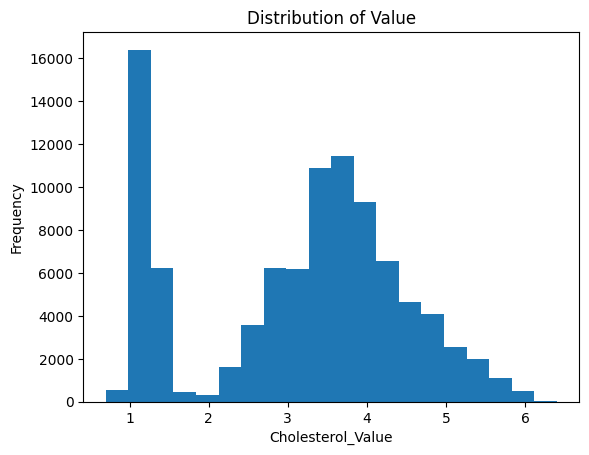

In [17]:
plt.figure()
plt.hist(df["NumericValue"], bins=20)
plt.xlabel("Cholesterol_Value")
plt.ylabel("Frequency")
plt.title("Distribution of Value")
plt.show()


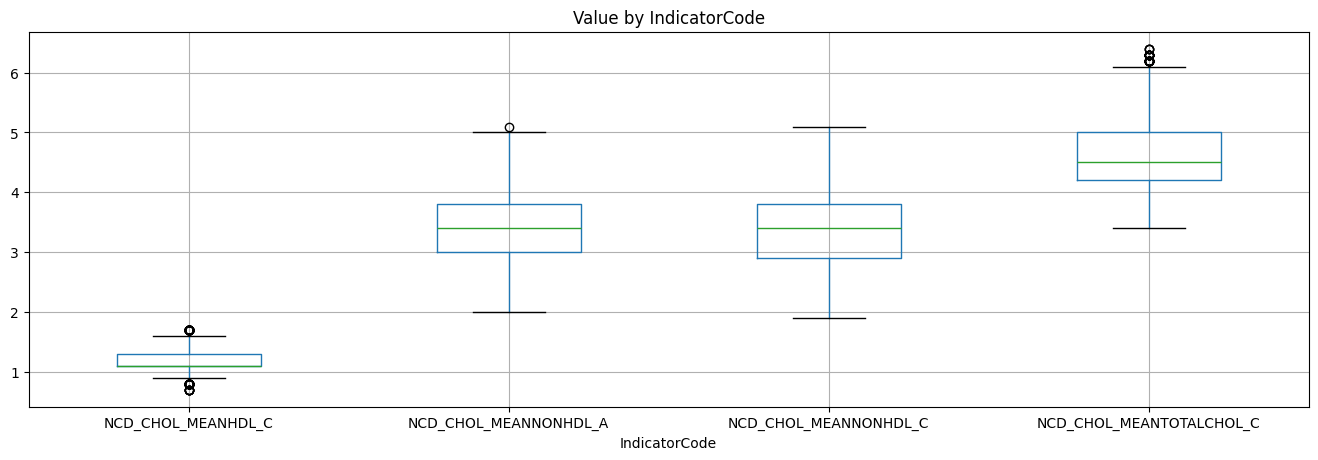

In [18]:
fig, ax = plt.subplots(figsize=(16,5))
df.boxplot(column="NumericValue", by="IndicatorCode", ax=ax)

ax.set_title("Value by IndicatorCode")
plt.suptitle("")
plt.show()